In [1]:
# CELL 1: Imports and Advanced Heuristic Dataset Generation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Machine Learning & Metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Visualization & Explainability
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Modern styling for academic graphs
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("mako")

print("Libraries imported successfully!")

def generate_sme_data(n_samples=100000, seed=42):
    """Generates highly realistic SME Supply Chain dataset."""
    np.random.seed(seed)
    print(f"Generating {n_samples:,} records with non-linear risk heuristics...")
    
    df = pd.DataFrame({
        "Annual_Income": np.random.lognormal(mean=12.5, sigma=0.8, size=n_samples).clip(50000, 5000000),
        "Debt_Ratio": np.random.beta(a=2, b=5, size=n_samples),
        "Loan_Amount": np.random.lognormal(mean=11.5, sigma=0.7, size=n_samples).clip(10000, 2000000),
        "Years_in_Business": np.random.randint(1, 25, n_samples),
        "Credit_History_Length": np.random.randint(1, 20, n_samples),
        "Previous_Defaults": np.random.poisson(lam=0.3, size=n_samples),
        "Supplier_Payment_Delay": np.random.normal(loc=15, scale=12, size=n_samples).clip(0, 90),
        "Inventory_Turnover": np.random.uniform(1, 20, n_samples),
        "Cash_Flow_Stability": np.random.beta(a=5, b=2, size=n_samples), 
        "Sector_Risk_Score": np.random.uniform(10, 90, n_samples),
        
        # Adding a pure noise variable to test if the Feature Selector successfully removes it
        "Random_Noise": np.random.normal(0, 1, n_samples)
    })

    # Complex risk probability calculation
    risk_prob = (
        0.35 * (df["Debt_Ratio"] > 0.55) + 
        0.25 * (df["Previous_Defaults"] >= 1) + 
        0.20 * (df["Cash_Flow_Stability"] < 0.3) + 
        0.10 * (df["Sector_Risk_Score"] > 70) + 
        0.10 * (df["Supplier_Payment_Delay"] > 30)
    )

    # Add statistical noise and threshold
    final_risk_score = risk_prob + np.random.uniform(-0.15, 0.15, n_samples)
    df["Risk"] = (final_risk_score > 0.45).astype(int)
    
    return df

df = generate_sme_data()
df.to_csv("kaggle_sme_credit_risk_100k.csv", index=False)

print(f"Dataset Shape: {df.shape}")
print(f"High Risk SMEs (1): {df['Risk'].sum():,} | Low Risk SMEs (0): {len(df) - df['Risk'].sum():,}")
display(df.head())

Libraries imported successfully!
Generating 100,000 records with non-linear risk heuristics...
Dataset Shape: (100000, 12)
High Risk SMEs (1): 5,040 | Low Risk SMEs (0): 94,960


,Annual_Income,Debt_Ratio,Loan_Amount,Years_in_Business,Credit_History_Length,Previous_Defaults,Supplier_Payment_Delay,Inventory_Turnover,Cash_Flow_Stability,Sector_Risk_Score,Random_Noise,Risk
0,399261.281500,0.566418,230923.886205,14,8,0,15.869898,17.278117,0.399590,67.786391,-0.397180,0
1,240238.764306,0.211394,67225.151817,7,9,0,17.296596,9.908890,0.814228,22.607558,0.258639,0
2,450516.882556,0.354759,237115.622111,9,14,0,40.302526,3.482181,0.805961,89.084440,1.389347,0
3,907477.349087,0.297004,63586.211289,11,19,0,27.635028,6.089602,0.627795,80.708056,0.172875,0
4,222498.869621,0.438507,288317.916873,21,18,0,9.550527,1.432499,0.797541,85.231249,0.956139,0


Generating Exploratory Data Analysis (EDA) visualizations...


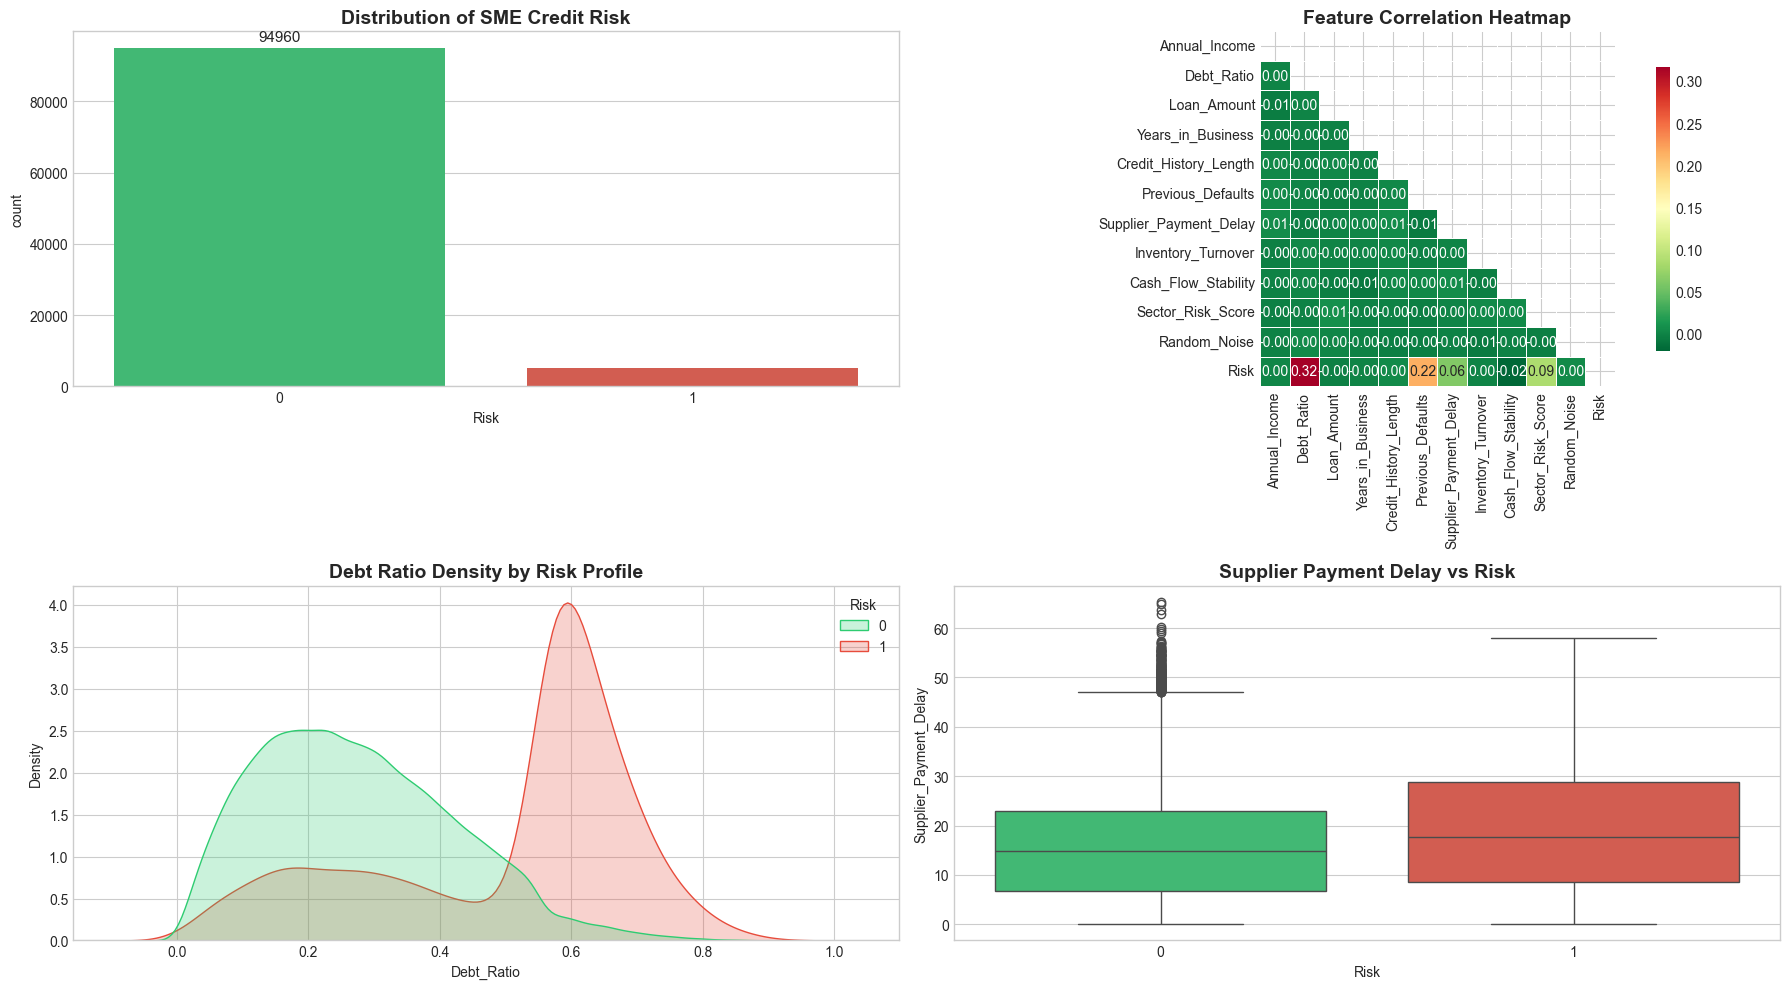

In [2]:
# CELL 2: Exploratory Data Analysis (EDA)
print("Generating Exploratory Data Analysis (EDA) visualizations...")

fig = plt.figure(figsize=(18, 10))

# 1. Target Distribution
plt.subplot(2, 2, 1)
ax = sns.countplot(data=df, x='Risk', palette=['#2ECC71', '#E74C3C'])
plt.title('Distribution of SME Credit Risk', fontsize=14, fontweight='bold')
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=11)

# 2. Optimized Correlation Matrix
plt.subplot(2, 2, 2)
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn_r', 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# 3. Debt Ratio KDE
plt.subplot(2, 2, 3)
sns.kdeplot(data=df, x='Debt_Ratio', hue='Risk', fill=True, palette=['#2ECC71', '#E74C3C'], common_norm=False)
plt.title('Debt Ratio Density by Risk Profile', fontsize=14, fontweight='bold')

# 4. Boxplot for Payment Delays
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Risk', y='Supplier_Payment_Delay', palette=['#2ECC71', '#E74C3C'])
plt.title('Supplier Payment Delay vs Risk', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [3]:
# CELL 3: Multi-Stage Feature Selection & Model Training Pipeline
print("Initiating Multi-Stage Feature Selection Pipeline...")

X = df.drop("Risk", axis=1)
y = df["Risk"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# STAGE 1: FILTER METHODS (Stats)
# ==========================================
print("\n[Stage 1] Statistical Filtering...")
# 1a. Variance Threshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)
X_train_f1 = X_train.loc[:, vt.get_support()]

# 1b. Correlation Removal (Drop highly correlated > 0.85)
corr_matrix = X_train_f1.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop =[column for column in upper.columns if any(upper[column] > 0.85)]
X_train_f1 = X_train_f1.drop(columns=to_drop)
print(f"  -> Features retained after Stage 1: {X_train_f1.shape[1]}")

# ==========================================
# STAGE 2 & 3: EMBEDDED STABILITY SELECTION 
# ==========================================
print("\n[Stage 2 & 3] LightGBM Stability Selection (Bootstrapping)...")
n_iterations = 5
feature_votes = pd.Series(0, index=X_train_f1.columns)

for seed in range(n_iterations):
    lgb_fs = LGBMClassifier(n_estimators=100, random_state=seed, n_jobs=-1, verbose=-1)
    lgb_fs.fit(X_train_f1, y_train)
    importances = pd.Series(lgb_fs.feature_importances_, index=X_train_f1.columns)
    feature_votes += (importances > importances.median()).astype(int)

stable_features = feature_votes[feature_votes >= (0.6 * n_iterations)].index.tolist()
print(f"  -> Final Stable Features Selected: {len(stable_features)}")
print(f"  -> {stable_features}")

X_train_sel = X_train_f1[stable_features]
X_test_sel = X_test[stable_features]

# ==========================================
# MODEL TRAINING & EVALUATION
# ==========================================
print("\nTraining Predictive Models (LightGBM, XGBoost, Random Forest)...")

models = {
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, verbose=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, eval_metric='logloss'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1)
}

metrics_list =[]
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    y_proba = model.predict_proba(X_test_sel)[:, 1]
    
    metrics_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(metrics_list).set_index("Model")
print("\nMODEL EVALUATION METRICS:")
display(results_df.style.highlight_max(color='lightgreen', axis=0).format("{:.4f}"))

best_model = models["LightGBM"]

Initiating Multi-Stage Feature Selection Pipeline...

[Stage 1] Statistical Filtering...
  -> Features retained after Stage 1: 11

[Stage 2 & 3] LightGBM Stability Selection (Bootstrapping)...
  -> Final Stable Features Selected: 5
  -> ['Debt_Ratio', 'Supplier_Payment_Delay', 'Cash_Flow_Stability', 'Sector_Risk_Score', 'Random_Noise']

Training Predictive Models (LightGBM, XGBoost, Random Forest)...

MODEL EVALUATION METRICS:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
LightGBM,0.9556,0.6245,0.2986,0.4040,0.9295
XGBoost,0.9555,0.6196,0.3006,0.4048,0.9287
Random Forest,0.9565,0.6547,0.2897,0.4017,0.9301


Generating SHAP Explainability & Advanced Metrics...


 99%|===================| 1979/2000 [01:19<00:00]        

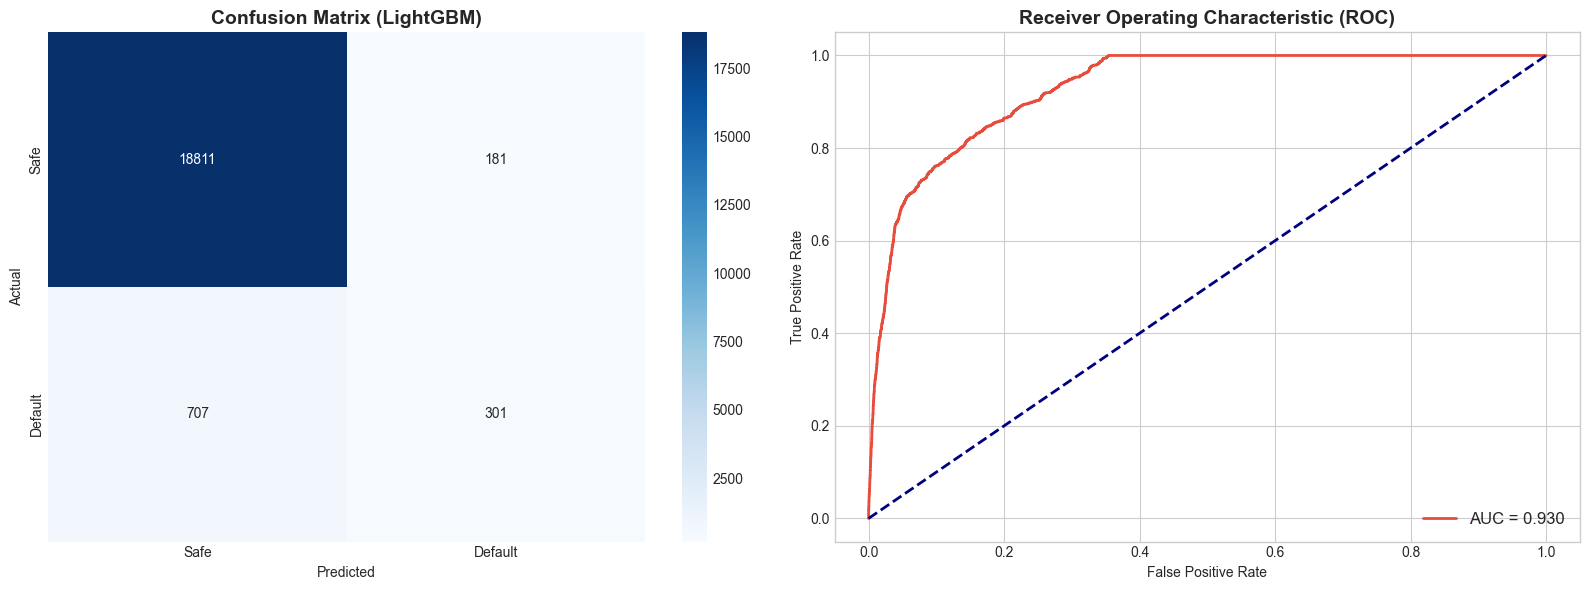

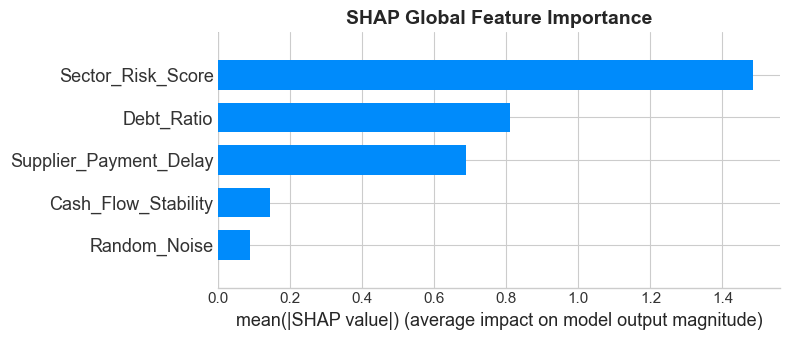

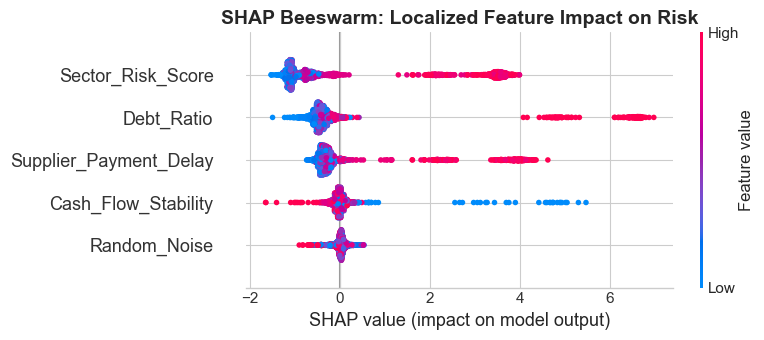

Visualizations generated successfully!


In [4]:
# CELL 4: Explainable AI (SHAP) & Advanced Metrics
from sklearn.metrics import confusion_matrix, roc_curve, auc

print("Generating SHAP Explainability & Advanced Metrics...")

# Calculate SHAP values using a sample of 2000 for faster processing
explainer = shap.Explainer(best_model, X_train_sel)
X_test_sample = X_test_sel.sample(2000, random_state=42)
shap_values = explainer(X_test_sample) 

# ==========================================
# FIGURE 1: Confusion Matrix & ROC Curve
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
y_pred_final = best_model.predict(X_test_sel)
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe', 'Default'], yticklabels=['Safe', 'Default'], ax=axes[0])
axes[0].set_title('Confusion Matrix (LightGBM)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
y_proba_final = best_model.predict_proba(X_test_sel)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
axes[1].plot(fpr, tpr, color='#E74C3C', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 2: SHAP Global Feature Importance
# ==========================================
plt.figure(figsize=(10, 5))
plt.title("SHAP Global Feature Importance", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 3: SHAP Beeswarm Plot
# ==========================================
plt.figure(figsize=(10, 6))
plt.title("SHAP Beeswarm: Localized Feature Impact on Risk", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.show()

print("Visualizations generated successfully!")

In [5]:
# CELL 5: Interactive Web Dashboard (Gradio Blocks)
import gradio as gr

print("Launching Modern Banking Dashboard (Gradio)...")

def predict_sme_risk(*inputs):
    input_df = pd.DataFrame([inputs], columns=stable_features)
    prob = best_model.predict_proba(input_df)[0][1]
    
    if prob >= 0.5:
        return f"HIGH RISK ({prob*100:.1f}%)", "Recommendation: Deny Loan or Require High Collateral."
    else:
        return f"SAFE ({prob*100:.1f}%)", "Recommendation: Approve Loan under standard terms."

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# SME Supply Chain Credit Risk Assessment")
    gr.Markdown("Adjust the financial parameters below based on the SME's supply chain data. The Explainable Model will update the risk assessment in real-time.")
    
    with gr.Row():
        with gr.Column():
            gr.Markdown("### Financial & Supply Chain Metrics")
            input_components =[]
            
            for feat in stable_features:
                if "Ratio" in feat or "Stability" in feat:
                    comp = gr.Slider(0.0, 1.0, value=0.5, step=0.01, label=feat.replace("_", " "))
                elif "Score" in feat:
                    comp = gr.Slider(0, 100, value=50, step=1, label=feat.replace("_", " "))
                elif "Defaults" in feat:
                    comp = gr.Slider(0, 10, value=0, step=1, label=feat.replace("_", " "))
                elif "Delay" in feat:
                    comp = gr.Slider(0, 90, value=15, step=1, label=feat.replace("_", " ") + " (Days)")
                else:
                    comp = gr.Number(value=50000, label=feat.replace("_", " "))
                input_components.append(comp)
                
            predict_btn = gr.Button("Evaluate Risk", variant="primary")
            
        with gr.Column():
            gr.Markdown("### Assessment Result")
            risk_output = gr.Textbox(label="Risk Status", text_align="center", scale=2)
            action_output = gr.Textbox(label="System Recommendation")

    predict_btn.click(predict_sme_risk, inputs=input_components, outputs=[risk_output, action_output])

demo.launch(inbrowser=False, share=False)

Launching Modern Banking Dashboard (Gradio)...
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
